# Bank Marketing — Term Deposit Subscription Classification

This case study develops a binary classification workflow using the UCI Bank Marketing dataset.

The modeling scenario is deliberately defined as a **pre-call scoring problem**: the bank wants to rank clients before the current campaign call takes place. That definition is important because several variables in the raw dataset describe the current contact itself and therefore cannot be treated as available predictors.

The work covers data-quality analysis, leakage handling, exploratory analysis, preprocessing, several classical classification models, cross-validation, regularization, hyperparameter search, and learning-curve analysis.

## 1. Dataset and setup

The dataset contains **45,211 observations** and 16 input variables plus the binary target `y`, which indicates whether the client subscribed to a term deposit.

The data is downloaded directly from the UCI archive when a local copy is not available.

In [27]:
import io
import urllib.request
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.stats import loguniform, uniform

from sklearn.base import BaseEstimator, TransformerMixin, OneToOneFeatureMixin
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    fbeta_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    cross_validate,
    learning_curve,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PowerTransformer, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils.validation import check_is_fitted, validate_data

RANDOM_STATE = 42

In [28]:
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

CSV_PATH = DATA_DIR / "bank-full.csv"

UCI_ZIP_URL = (
    "https://archive.ics.uci.edu/static/public/222/"
    "bank%2Bmarketing.zip"
)


def extract_from_nested_zip(zip_bytes, target_filename):
    """Find a file inside a ZIP archive, including nested ZIP archives."""
    with zipfile.ZipFile(io.BytesIO(zip_bytes)) as zf:
        for name in zf.namelist():
            if Path(name).name.lower() == target_filename.lower():
                return zf.read(name)

        for name in zf.namelist():
            if name.lower().endswith(".zip"):
                nested_bytes = zf.read(name)
                try:
                    result = extract_from_nested_zip(
                        nested_bytes,
                        target_filename
                    )
                    if result is not None:
                        return result
                except zipfile.BadZipFile:
                    pass

    return None


if not CSV_PATH.exists():
    print("Downloading UCI Bank Marketing dataset...")

    with urllib.request.urlopen(UCI_ZIP_URL) as response:
        zip_bytes = response.read()

    csv_bytes = extract_from_nested_zip(
        zip_bytes,
        "bank-full.csv"
    )

    if csv_bytes is None:
        raise FileNotFoundError(
            "Could not locate bank-full.csv inside the UCI archive."
        )

    df = pd.read_csv(
        io.BytesIO(csv_bytes),
        sep=";"
    )

    df.to_csv(CSV_PATH, index=False)
    print(f"Saved local copy to {CSV_PATH}")

else:
    df = pd.read_csv(CSV_PATH)


print(df.shape)
df.head()

(45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## 2. Initial data-quality assessment

The raw table has no native `NaN` values and no exact duplicate rows. Missing or unavailable information is instead represented through domain-specific conventions such as the string `"unknown"` and the sentinel value `pdays = -1`.

The target is imbalanced: only about **11%** of observations belong to the positive class. This makes accuracy insufficient as a standalone evaluation metric.

In [29]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB
None


In [30]:
df.duplicated().value_counts()

False    45211
Name: count, dtype: int64

In [31]:
cat_columns = df.select_dtypes(include=["object", "string"])
cat_columns.describe()


,job,marital,education,default,housing,loan,contact,month,poutcome,y
count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
unique,12,3,4,2,2,2,3,12,4,2
top,blue-collar,married,secondary,no,yes,no,cellular,may,unknown,no
freq,9732,27214,23202,44396,25130,37967,29285,13766,36959,39922


In [32]:
bool_na_df = cat_columns.replace('unknown', pd.NA).isna()
bool_na_df.sum()

job            288
marital          0
education     1857
default          0
housing          0
loan             0
contact      13020
month            0
poutcome     36959
y                0
dtype: int64

In [33]:
uncontacted_bool_series = (df['pdays'] != -1).value_counts()

uncontacted_bool_series[False]/(uncontacted_bool_series.sum())

np.float64(0.8173674548229414)

In [34]:
pd.crosstab(
    df["pdays"] == -1,
    df["poutcome"]    
)

poutcome,failure,other,success,unknown
pdays,,,,
False,4901,1840,1511,5
True,0,0,0,36954


In [35]:
pd.crosstab(df["pdays"] == -1,
            df["contact"])

contact,cellular,telephone,unknown
pdays,,,
False,7556,631,70
True,21729,2275,12950


In [36]:
df.copy().select_dtypes(include='number').describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [37]:
target_counts = df['y'].value_counts()

yes_count = target_counts['yes']
no_count = target_counts['no']

print("Positive Count: ", yes_count)
print("Negative count: ", no_count)
print("Positive Proportion: ", yes_count/(yes_count + no_count))

Positive Count:  5289
Negative count:  39922
Positive Proportion:  0.11698480458295547


The previous-campaign variables require semantic treatment rather than generic missing-value handling. Roughly 81% of observations have `pdays = -1`, which indicates that the client had not been contacted in a previous campaign. In `poutcome`, most `"unknown"` values are explained by the same situation. Five observations show `poutcome = "unknown"` despite indicating a previous contact; without additional process metadata, these were treated as data-quality anomalies.

The raw `contact` variable also appears for clients with no previous campaign contact. Under the pre-call scoring definition used here, this field is considered information from the current campaign and is therefore excluded from modeling.

### Reproducible quality report

In [38]:
work_df = df.copy()


In [39]:
def summarize_column(x: pd.Series) -> pd.Series:
    is_numeric = pd.api.types.is_numeric_dtype(x)
    is_categorical = x.dtype in [object, str]

    return pd.Series({
        "dtype" : x.dtype,
        "n_missing": x.isna().sum(),
        "pct_missing (%)": x.isna().sum()/len(x)*100,
        "n_unknown": (x == 'unknown').sum() if is_categorical else pd.NA,
        "pct_unknown (%)": (x == 'unknown').sum()/len(x)*100 if is_categorical else pd.NA,
        "n_unique": len(x.drop_duplicates()) if is_categorical else pd.NA,
        "feature_min": x.min() if is_numeric else pd.NA,
        "feature_max": x.max() if is_numeric else pd.NA,
        "feature_mean": x.mean() if is_numeric else pd.NA,
        "most_frequent": x.value_counts().head(3).index.to_list() if is_categorical else pd.NA
    })

quality_report = work_df.apply(summarize_column, axis = 0).T

quality_report

,dtype,n_missing,pct_missing (%),n_unknown,pct_unknown (%),n_unique,feature_min,feature_max,feature_mean,most_frequent
age,int64,0,0.0,<NA>,<NA>,<NA>,18,95,40.93621,<NA>
job,object,0,0.0,288,0.637013,12,<NA>,<NA>,<NA>,"[blue-collar, management, technician]"
marital,object,0,0.0,0,0.0,3,<NA>,<NA>,<NA>,"[married, single, divorced]"
education,object,0,0.0,1857,4.107407,4,<NA>,<NA>,<NA>,"[secondary, tertiary, primary]"
default,object,0,0.0,0,0.0,2,<NA>,<NA>,<NA>,"[no, yes]"
balance,int64,0,0.0,<NA>,<NA>,<NA>,-8019,102127,1362.272058,<NA>
housing,object,0,0.0,0,0.0,2,<NA>,<NA>,<NA>,"[yes, no]"
loan,object,0,0.0,0,0.0,2,<NA>,<NA>,<NA>,"[no, yes]"
contact,object,0,0.0,13020,28.798301,3,<NA>,<NA>,<NA>,"[cellular, unknown, telephone]"
day,int64,0,0.0,<NA>,<NA>,<NA>,1,31,15.806419,<NA>


age            Axes(0.125,0.11;0.133621x0.77)
balance     Axes(0.285345,0.11;0.133621x0.77)
duration     Axes(0.44569,0.11;0.133621x0.77)
campaign    Axes(0.606034,0.11;0.133621x0.77)
previous    Axes(0.766379,0.11;0.133621x0.77)
dtype: object

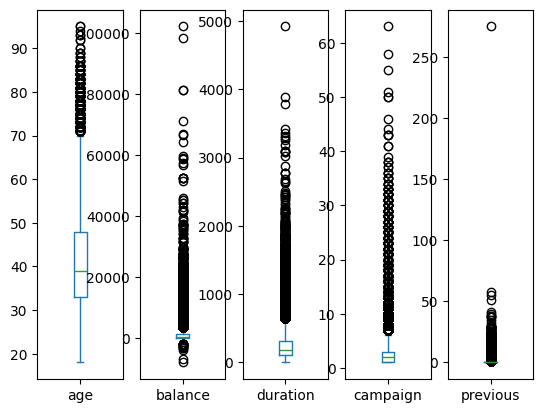

In [40]:
work_df[['age', 'balance', 'duration', 'campaign', 'previous']].plot(kind='box', subplots=True)

### Cleaning decisions

`"unknown"` is retained as a valid category for `job` and `education`. Without stronger domain information, imputing those values would introduce assumptions that are not supported by the data.

`pdays = -1` is treated as a sentinel rather than as an ordinary numerical value. A binary `contacted_before` feature preserves the information that a previous contact did or did not occur, while valid elapsed-day values are stored separately in `days_since_last_contact`.

The current-call variables `contact`, `day`, `month`, `duration`, and `campaign` are excluded because the model is intended to score clients **before the current call**. The isolated observation with `previous = 275` is also removed because it is an extreme value relative to the rest of that feature and no business context is available to validate it.

Six rows are removed in total: the five inconsistent previous-contact records and the single extreme `previous` observation.

In [41]:
quality_anomaly_mask = (
    ((work_df["pdays"] != -1) &
     (work_df["poutcome"] == "unknown")) |
    (work_df["previous"] == 275)
)

clean_df = (
    work_df
    .loc[~quality_anomaly_mask]
    .assign(
        contacted_before=lambda x: x["pdays"] != -1,
        days_since_last_contact=lambda x: x["pdays"].where(
            x["pdays"] != -1,
            np.nan
        ),
        target=lambda x: (x["y"] == "yes").astype(int)
    )
    .drop(
        columns=[
            "contact",
            "day",
            "month",
            "duration",
            "campaign",
            "pdays",
            "y",
        ]
    )
)

clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45205 entries, 0 to 45210
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      45205 non-null  int64  
 1   job                      45205 non-null  object 
 2   marital                  45205 non-null  object 
 3   education                45205 non-null  object 
 4   default                  45205 non-null  object 
 5   balance                  45205 non-null  int64  
 6   housing                  45205 non-null  object 
 7   loan                     45205 non-null  object 
 8   previous                 45205 non-null  int64  
 9   poutcome                 45205 non-null  object 
 10  contacted_before         45205 non-null  bool   
 11  days_since_last_contact  8251 non-null   float64
 12  target                   45205 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(7)
memory usage: 4.5+ MB


## 3. Exploratory analysis

The exploratory analysis focused on the distributions that directly affected modeling decisions.

- More than 80% of `previous` values are zero. Among nonzero observations, the distribution is strongly right-skewed.
- `age` is concentrated mostly between 20 and 60 years, with a comparatively small upper tail.
- `balance` contains a meaningful fraction of negative values and a long positive tail. Approximately 8.3% of observations have negative balances; the median is 448, while the maximum exceeds 100,000.
- `days_since_last_contact` is multimodal rather than smoothly monotonic. Conversion rates across elapsed-time bins also vary non-monotonically, motivating a nonlinear representation of this feature.

In [42]:
display("'Previous' percentages")
display(clean_df['previous'].describe(percentiles=[0.10, 0.25, 0.5, 0.7, 0.8, 0.9, 0.99]))

display("'Previous' percentages drop '0'")
display(clean_df['previous'][clean_df['previous'] > 0].describe(percentiles=[0.10, 0.25, 0.5, 0.7, 0.8, 0.9, 0.99]))

"'Previous' percentages"

count    45205.000000
mean         0.573941
std          1.907655
min          0.000000
10%          0.000000
25%          0.000000
50%          0.000000
70%          0.000000
80%          0.000000
90%          2.000000
99%          8.000000
max         58.000000
Name: previous, dtype: float64

"'Previous' percentages drop '0'"

count    8251.000000
mean        3.144467
std         3.443251
min         1.000000
10%         1.000000
25%         1.000000
50%         2.000000
70%         3.000000
80%         4.000000
90%         6.000000
99%        17.000000
max        58.000000
Name: previous, dtype: float64

<Axes: >

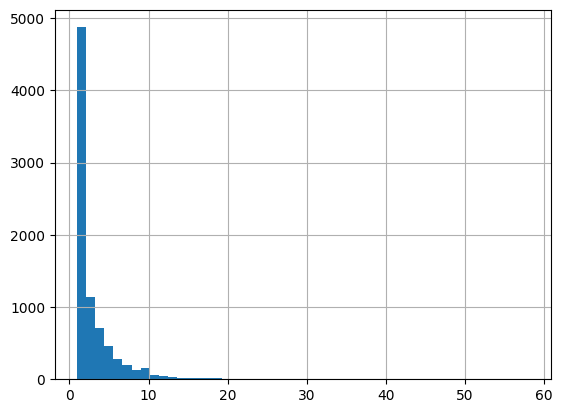

In [43]:
clean_df['previous'][clean_df['previous'] > 0].hist(bins = 50)

<Axes: >

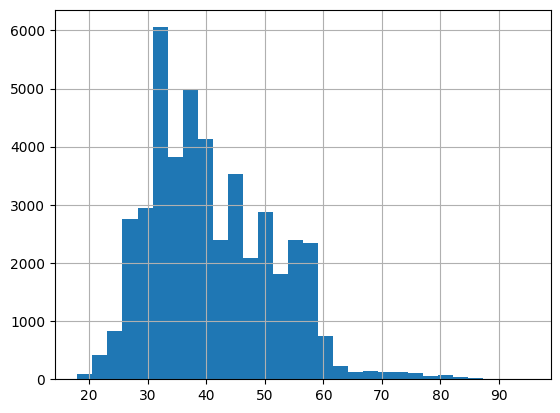

In [44]:
clean_df['age'].hist(bins = 30)

In [45]:
negative_percentile = (clean_df["balance"] < 0).mean()
cero_percentile = (clean_df["balance"] <= 0).mean()

display(clean_df['balance'].describe(percentiles=[negative_percentile, cero_percentile, 0.25, 0.5, 0.7, 0.8, 0.9, 0.99]))

count     45205.000000
mean       1362.349607
std        3044.935824
min       -8019.000000
8.3%         -0.083309
16.1%         0.838956
25%          72.000000
50%         448.000000
70%        1126.000000
80%        1859.200000
90%        3574.600000
99%       13164.960000
max      102127.000000
Name: balance, dtype: float64

<Axes: >

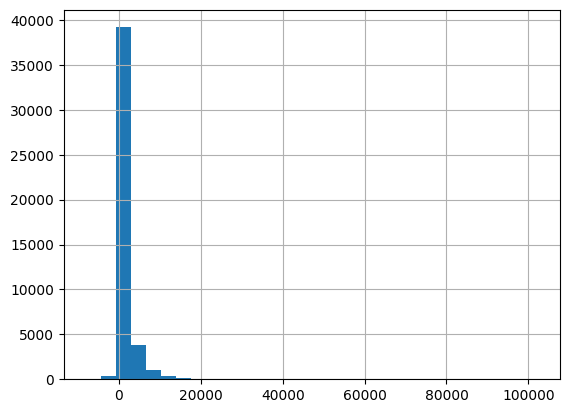

In [46]:
clean_df['balance'].hist(bins = 30)

<Axes: >

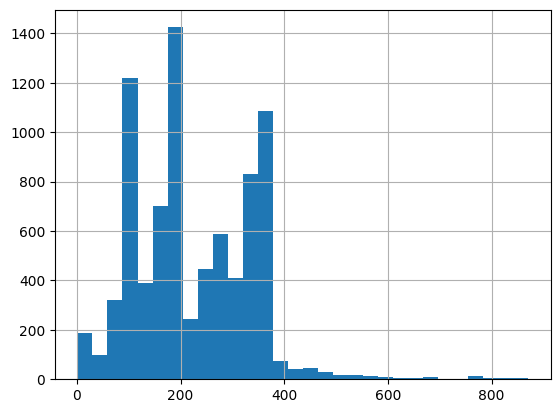

In [47]:
clean_df['days_since_last_contact'].hist(bins = 30)

In [48]:
tmp = (
    clean_df.loc[clean_df["contacted_before"]]
    .assign(
        days_bin=lambda x: pd.qcut(
            x["days_since_last_contact"],
            q=10,
            duplicates="drop"
        )
    )
    .groupby("days_bin", observed=True)
    .agg(
        n=("target", "size"),
        conversion_rate=("target", "mean")
    )
)

tmp

,n,conversion_rate
days_bin,,
"(0.999, 91.0]",844,0.386256
"(91.0, 108.0]",816,0.435049
"(108.0, 159.0]",819,0.161172
"(159.0, 181.0]",834,0.229017
"(181.0, 194.0]",813,0.387454
"(194.0, 258.0]",833,0.147659
"(258.0, 300.0]",824,0.144417
"(300.0, 343.0]",879,0.096701
"(343.0, 362.0]",765,0.075817


### Categorical relationships

Conversion rates were inspected across the retained categorical variables. The observed categories were sufficiently represented to make their empirical rates useful for exploratory comparison, while avoiding causal interpretation.

A specific interaction was also examined between `housing` and `loan`. Clients without either type of loan showed the highest observed conversion rate, while the effect associated with a personal loan differed depending on housing-loan status. This suggested `housing × loan` as a possible interaction term for a linear model.

In [49]:
clean_cat_df = clean_df.copy().select_dtypes(include=['object', 'string'])
for column in clean_cat_df.items():
    display(column[1].value_counts())

job
blue-collar      9732
management       9455
technician       7596
admin.           5170
services         4154
retired          2263
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

marital
married     27210
single      12788
divorced     5207
Name: count, dtype: int64

education
secondary    23199
tertiary     13298
primary       6851
unknown       1857
Name: count, dtype: int64

default
no     44390
yes      815
Name: count, dtype: int64

housing
yes    25127
no     20078
Name: count, dtype: int64

loan
no     37963
yes     7242
Name: count, dtype: int64

poutcome
unknown    36954
failure     4901
other       1839
success     1511
Name: count, dtype: int64

In [50]:
def show_bar_by_target_plot(column: str):
    target_by_group = clean_df.groupby(column, as_index=False).agg(
        n = ('target', 'size'),
        conversion_rate = ('target', 'mean')
    ).sort_values('conversion_rate', ascending=False)

    bars = plt.bar(target_by_group[column], target_by_group['conversion_rate'])

    plt.bar_label(
        bars,
        labels=[f"n={n}" for n in target_by_group["n"]],
        padding=3
    )

    plt.xticks(rotation='vertical')
    plt.show()

job


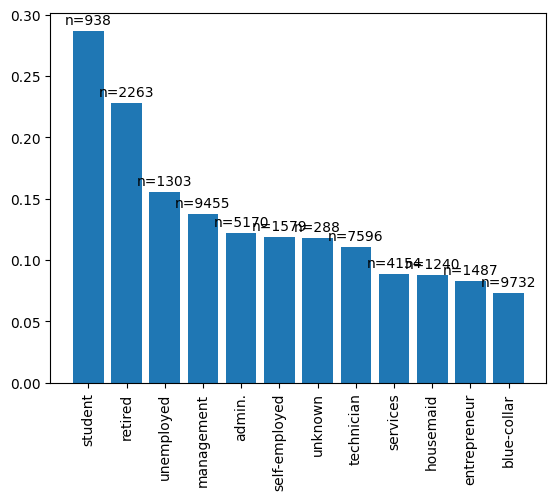

marital


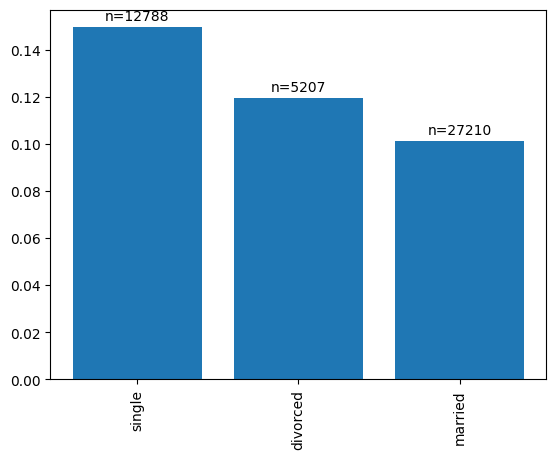

education


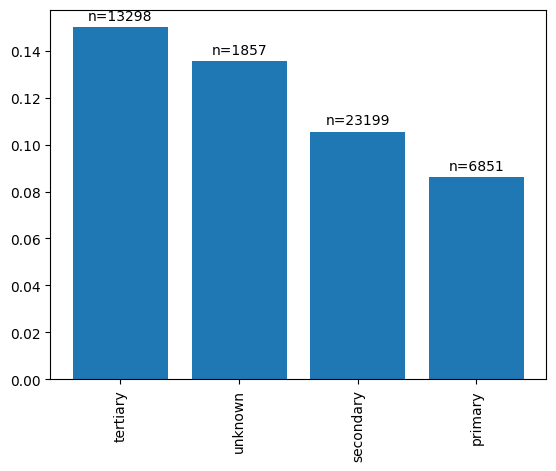

default


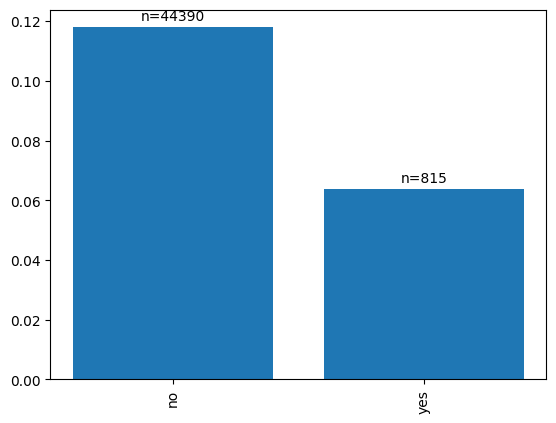

housing


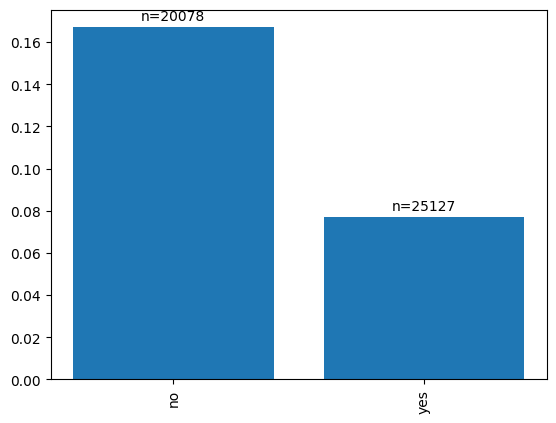

loan


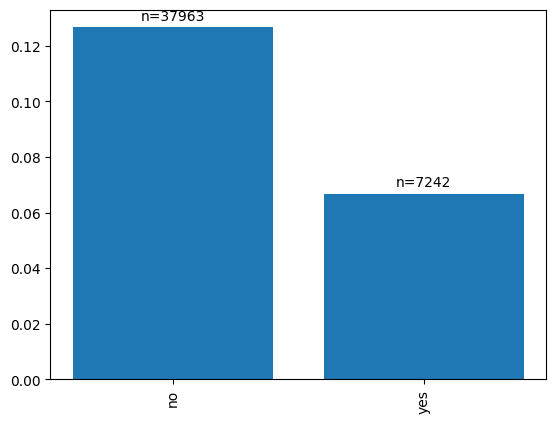

poutcome


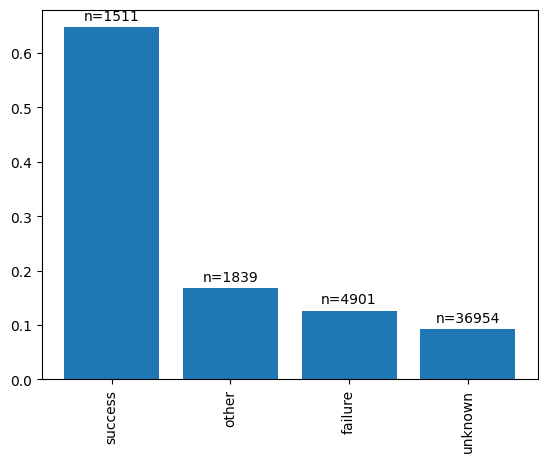

In [51]:
categorical_cols = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
    "poutcome"
]

for column in categorical_cols:
    print(column)
    show_bar_by_target_plot(column)

In [52]:
display("Conversion Rate")
display(
    clean_df.pivot_table(
        index="housing",
        columns="loan",
        values="target",
        aggfunc="mean",
    )
)

display("n")
display(
    clean_df.pivot_table(
        index="housing",
        columns="loan",
        values="target",
        aggfunc="size",
    )
)

'Conversion Rate'

loan,no,yes
housing,,
no,0.182199,0.076121
yes,0.080435,0.060481


'n'

loan,no,yes
housing,,
no,17201,2877
yes,20762,4365


## 4. Leakage definition and train/test split

The target is the binary `target` column derived from `y`. All predictors in `X` are intended to represent information available before the current campaign call.

Cross-validation cannot repair feature leakage: if a predictor contains information that would not exist at scoring time, every fold still contains that invalid information. Entity leakage also cannot be ruled out from this dataset because no client identifier is available to verify whether the same client appears multiple times.

An 80/20 stratified split is used so that the minority-class proportion remains almost identical in training and test data.

In [53]:
X = clean_df.copy().drop(columns = ['target'])
y = clean_df.copy()['target']

In [54]:
RANDOM_STATE = 27

In [55]:

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=RANDOM_STATE,
                 stratify=y)

print('Train Target Balance: ', y_train.mean())
print('Test Target Balance: ', y_test.mean())


Train Target Balance:  0.11696714965158721
Test Target Balance:  0.11691184603473068


## 5. Preprocessing

The preprocessing strategy reflects the observed distributions and the requirements of the candidate models:

- categorical variables are one-hot encoded with unknown-category handling;
- `previous` is transformed with `log1p` and standardized;
- `age` is standardized;
- `balance` is transformed with Yeo–Johnson, which can handle negative values;
- `days_since_last_contact` is represented through similarities to K-Means-derived centers using an RBF kernel;
- the remaining features are passed through unchanged.

The complete preprocessing object is placed inside each scikit-learn pipeline so that fitted transformations are learned only from training folds during cross-validation.

### Custom transformers

In [56]:
class Log1pTransformer(
    OneToOneFeatureMixin,
    TransformerMixin,
    BaseEstimator
):

    def fit(self, X, y=None):
        X = validate_data(
            self,
            X,
            reset=True,
            ensure_all_finite="allow-nan"
        )

        self._check_domain(X)
        return self

    def transform(self, X):
        X = validate_data(
            self,
            X,
            reset=False,
            ensure_all_finite="allow-nan"
        )

        self._check_domain(X)
        return np.log1p(X)

    def inverse_transform(self, X):
        X = validate_data(
            self,
            X,
            reset=False,
            ensure_all_finite="allow-nan"
        )

        return np.expm1(X)

    def _check_domain(self, X):
        if np.any(X <= -1):
            raise ValueError(
                "Log1pTransformer requires values > -1."
            )

class ClusterProximity(BaseEstimator, TransformerMixin):

    def __init__(
        self,
        n_clusters=4,
        gamma=7e-5,
        allow_na=True,
        random_state=None
    ):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.allow_na = allow_na
        self.random_state = random_state

    def fit(self, X, y=None):

        X = validate_data(
            self,
            X,
            reset=True,
            ensure_all_finite="allow-nan"
            if self.allow_na else True
        )

        valid_mask = ~np.isnan(X).any(axis=1)
        X_valid = X[valid_mask]

        if len(X_valid) < self.n_clusters:
            raise ValueError(
                "Number of valid observations must be "
                "at least n_clusters."
            )

        self.kmeans_ = KMeans(
            n_clusters=self.n_clusters,
            random_state=self.random_state
        )

        self.kmeans_.fit(X_valid)

        self.clusters_ = self.kmeans_.cluster_centers_

        return self

    def transform(self, X):

        check_is_fitted(self, attributes=["clusters_"])

        X = validate_data(
            self,
            X,
            reset=False,
            ensure_all_finite="allow-nan"
            if self.allow_na else True
        )

        valid_mask = ~np.isnan(X).any(axis=1)

        similarities = np.zeros(
            (X.shape[0], self.n_clusters)
        )

        similarities[valid_mask] = rbf_kernel(
            X[valid_mask],
            self.clusters_,
            gamma=self.gamma
        )

        return similarities

    def get_feature_names_out(self, input_features=None):

        return np.array([
            f"cluster_{i}_similarity"
            for i in range(self.n_clusters)
        ])

In [57]:
cat_columns = clean_cat_df.columns.to_list()
cat_columns

['job', 'marital', 'education', 'default', 'housing', 'loan', 'poutcome']

In [58]:
cat_pipeline = Pipeline([
    ("one-hot-encoder", OneHotEncoder(handle_unknown='ignore'))
])

log_pipeline = Pipeline([
    ('log_transformer', Log1pTransformer()),
    ('standard_scaler', StandardScaler())
])

preprocessing = ColumnTransformer([
    ('categorical', cat_pipeline, cat_columns),
    ('contact_days_cluster', ClusterProximity(random_state=RANDOM_STATE), ['days_since_last_contact']),
    ('previous_log_scale', log_pipeline, ['previous']),
    ('age_scaler', StandardScaler(), ['age']),
    ('balance_yeo_johnson', PowerTransformer(), ['balance']),
], remainder='passthrough')



Scaling is important for the linear and kernel-based models because feature magnitude affects optimization, regularization, and distance calculations. Tree models do not require scaling in the same way because their splits depend on thresholds and ordering rather than Euclidean scale.

`OneHotEncoder(handle_unknown="ignore")` allows categories not observed during fitting to be represented without raising an error; their encoded indicators are set to zero.

## 6. Baseline and evaluation metrics

Because the positive class represents only about 11% of the data, evaluation emphasizes ranking and minority-class behavior rather than accuracy alone.

The reusable evaluation function reports accuracy, precision, recall, specificity, F1, F2, Average Precision, and ROC AUC. Average Precision is particularly useful here because it summarizes how concentrated true positives are among high-scoring observations as recall increases. ROC AUC is still reported, but on an imbalanced dataset its false-positive-rate denominator is dominated by the majority class and can make performance look more favorable than the precision-recall view.

F2 is also included because it weights recall more strongly than precision when false negatives are considered more costly.

In [59]:
def evaluate_classifier(model, X, y,
                        threshold = None):

    # For this iteration we assume that we have atleast one of the two methods
    if getattr(model, "predict_proba", False):
        y_scores = model.predict_proba(X)[:, 1] 
    else:
        y_scores = model.decision_function(X)

    if threshold is None:
        y_pred = model.predict(X)
    else:
        y_pred = (y_scores > threshold)


    return {
        'accuracy': accuracy_score(y, y_pred),
        'precision': precision_score(y, y_pred),
        'recall': recall_score(y,y_pred),
        'specificity': recall_score(y, y_pred, pos_label=0),
        'f1': fbeta_score(y, y_pred, beta=1),
        'f2': fbeta_score(y, y_pred, beta=2),
        'average_precision': average_precision_score(y, y_scores),
        'roc-auc': roc_auc_score(y, y_scores)
    }    

In [60]:
dummy_classifier = Pipeline([
    ('processing', preprocessing),
    ('classifier', DummyClassifier(random_state = RANDOM_STATE, strategy='uniform'))
])
dummy_classifier.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('processing', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['age','job','marital',...,'poutcome','contacted_before', 'days_since_last_contact']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('contact_days_cluster', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).B

In [61]:
evaluate_classifier(dummy_classifier, X_test, y_test)

{'accuracy': 0.5063599159385024,
 'precision': 0.11730337078651686,
 'recall': 0.4938505203405866,
 'specificity': 0.5080160320641283,
 'f1': 0.18957690212456874,
 'f2': 0.3007605439041254,
 'average_precision': 0.11691184603473068,
 'roc-auc': 0.5}

The uniform dummy classifier produces an Average Precision of approximately **0.117**, essentially matching the positive-class prevalence, and a ROC AUC of **0.50**. This provides a minimal reference point for the trained classifiers.

## 7. Candidate models

Six classical classifier families were evaluated using the same preprocessing pipeline:

- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting
- SGD linear classifier with hinge loss
- RBF-kernel SVC

The models span linear and nonlinear decision boundaries, low- and high-variance learners, bagging, boosting, and kernel methods.

Logistic Regression and the SGD classifier provide linear decision functions and benefit from scaling and regularization. A single Decision Tree can capture nonlinear interactions without scaling but has high variance when left largely unconstrained. Random Forest reduces that variance by aggregating decorrelated trees. Gradient Boosting builds trees sequentially to correct previous errors, trading learning rate, tree complexity, and number of stages. RBF SVC can form nonlinear boundaries through distance-based kernel similarities but is sensitive to feature scale and is computationally more expensive as the number of observations grows.

In [62]:
models = {}

In [63]:
logistic_classifier = Pipeline([
    ('processing', preprocessing),
    ('classifier', LogisticRegression(random_state = RANDOM_STATE, solver='saga'))
])
logistic_classifier.fit(X_train, y_train)
models['logistic_regression'] = logistic_classifier

c:\Users\avado\OneDrive\Desktop\DataEngineeringStudy\Repository\data-ai-engineering-portfolio\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [64]:
tree_classifier = Pipeline([
    ('processing', preprocessing),
    ('classifier', DecisionTreeClassifier(random_state = RANDOM_STATE))
])
tree_classifier.fit(X_train, y_train)
models['tree_classifier'] = tree_classifier

In [65]:
random_forest_classifier = Pipeline([
    ('processing', preprocessing),
    ('classifier', RandomForestClassifier(n_estimators=500, random_state = RANDOM_STATE, max_depth=12, n_jobs=-1))
])
random_forest_classifier.fit(X_train, y_train)
models['random_forest_classifier'] = random_forest_classifier

In [66]:
gradient_boost_classifier = Pipeline([
    ('processing', preprocessing),
    ('classifier', GradientBoostingClassifier(random_state = RANDOM_STATE, n_estimators=500, learning_rate= 0.05, max_depth=10))
])
gradient_boost_classifier.fit(X_train, y_train)
models['gradient_boost_classifier'] = gradient_boost_classifier

In [67]:
sgd_classifier = Pipeline([
    ("preprocessing", preprocessing),
    ("classifier", SGDClassifier(
        loss="hinge",
        penalty="l2",
        alpha=1e-6,
        max_iter=1000,
        tol=1e-3,
        random_state=RANDOM_STATE
    ))
])

sgd_classifier.fit(X_train, y_train)
models['sgd_classifier'] = sgd_classifier

In [68]:
svc_classifier = Pipeline([
    ("preprocessing", preprocessing),
    ("classifier", SVC(kernel = 'rbf', random_state=RANDOM_STATE
    ))
])

svc_classifier.fit(X_train, y_train)
models['svc_classifier'] = svc_classifier

## 8. Stratified cross-validation

Five-fold stratified cross-validation is used on the training set. Stratification keeps the minority-class proportion approximately stable across folds, which is especially important for metrics such as recall, F1, and Average Precision.

The standard deviation across folds is treated as a measure of sensitivity to the particular train/validation partition rather than as a confidence interval.

In [69]:
def get_metrics_avg_std(X,y, model, n_splits = 5,
                        scoring = ['f1', 'recall', 'average_precision', 'roc_auc']):

    cv = StratifiedKFold(random_state = RANDOM_STATE,
                     shuffle=True, n_splits= n_splits)

    scores = cross_validate(model, X, y, scoring=scoring, cv = cv)

    for metric in ["average_precision", "roc_auc", "f1", "recall"]:
        values = scores[f"test_{metric}"]

        print(
            metric,
            "mean =", values.mean(),
            "std =", values.std()
        )

In [70]:

for model in models:
    print(model)
    get_metrics_avg_std(X_train, y_train, models[model])

    print("\n")

logistic_regression


c:\Users\avado\OneDrive\Desktop\DataEngineeringStudy\Repository\data-ai-engineering-portfolio\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\avado\OneDrive\Desktop\DataEngineeringStudy\Repository\data-ai-engineering-portfolio\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\avado\OneDrive\Desktop\DataEngineeringStudy\Repository\data-ai-engineering-portfolio\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\avado\OneDrive\Desktop\DataEngineeringStudy\Repository\data-ai-engineering-portfolio\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  war

average_precision mean = 0.351053119833233 std = 0.012182729707213872
roc_auc mean = 0.7188368940864861 std = 0.009631023931620325
f1 mean = 0.2673474644469252 std = 0.015590211943912925
recall mean = 0.166903073286052 std = 0.01109852916719197


tree_classifier
average_precision mean = 0.15370899257246282 std = 0.0031591493981184024
roc_auc mean = 0.5812726267444144 std = 0.004641593145480231
f1 mean = 0.2595277669721637 std = 0.008020622449196073
recall mean = 0.26832151300236406 std = 0.009002095869815508


random_forest_classifier
average_precision mean = 0.39327070345510257 std = 0.013855230459591358
roc_auc mean = 0.7381799718813122 std = 0.007537314207835533
f1 mean = 0.2714043079603105 std = 0.015887836393939824
recall mean = 0.16950354609929077 std = 0.011426048201980683


gradient_boost_classifier
average_precision mean = 0.3374621399219216 std = 0.018780542563215718
roc_auc mean = 0.6982794729021566 std = 0.011162223372723103
f1 mean = 0.29131370090143394 std = 0.01217883302

### Cross-validation summary

| Model | Average Precision | ROC AUC | F1 | Recall |
|---|---:|---:|---:|---:|
| Logistic Regression | 0.3508 ± 0.0119 | 0.7187 ± 0.0096 | 0.2676 ± 0.0144 | 0.1671 ± 0.0103 |
| Decision Tree | 0.1537 ± 0.0032 | 0.5813 ± 0.0046 | 0.2595 ± 0.0080 | 0.2683 ± 0.0090 |
| Random Forest | **0.3933 ± 0.0139** | **0.7382 ± 0.0075** | 0.2714 ± 0.0159 | 0.1695 ± 0.0114 |
| Gradient Boosting | 0.3375 ± 0.0188 | 0.6983 ± 0.0112 | **0.2913 ± 0.0122** | 0.1988 ± 0.0101 |
| SGD (hinge) | 0.2766 ± 0.0424 | 0.6423 ± 0.0372 | 0.2138 ± 0.1134 | 0.2882 ± 0.2479 |
| RBF SVC | 0.3081 ± 0.0128 | 0.6346 ± 0.0104 | 0.2746 ± 0.0067 | 0.1723 ± 0.0059 |

Among the evaluated models, Random Forest produced the strongest mean Average Precision and ROC AUC. Gradient Boosting produced the highest mean F1 in this comparison. The SGD classifier showed substantially higher fold-to-fold variability than the other models.

If repeated observations from the same client were available, a row-wise split would not be sufficient for evaluating generalization to new clients. A group-aware strategy such as `GroupKFold` or `StratifiedGroupKFold` would then be more appropriate. Similarly, a future-oriented production objective would motivate `TimeSeriesSplit` when a trustworthy temporal ordering is available.

## 9. Logistic Regression regularization

Logistic Regression was used as a regularization laboratory, comparing L1, L2, and Elastic Net configurations over several values of `C`.

In scikit-learn, larger `C` means weaker regularization. L1 encourages sparse coefficients, L2 shrinks coefficients continuously, and Elastic Net interpolates between the two.

In [71]:
base_logistic_classifier = Pipeline([
    ('processing', preprocessing),
    ('classifier', LogisticRegression(random_state = RANDOM_STATE, solver='saga'))
])

In [72]:
param_grid = [
    {
        "classifier__penalty": ["l1", "l2"],
        "classifier__C": [0.01, 0.1, 1, 10]
    },
    {
        "classifier__penalty": ["elasticnet"],
        "classifier__C": [0.01, 0.1, 1, 10],
        "classifier__l1_ratio": [0.1, 0.5, 0.9]
    }
]

In [73]:
cv = StratifiedKFold(random_state = RANDOM_STATE,
                     shuffle=True)

In [74]:
search = GridSearchCV(
    base_logistic_classifier,
    param_grid,
    scoring=['f1', 'recall', 'average_precision', 'roc_auc'],
    cv = cv,
    refit='f1'
)

In [75]:
search.fit(X_train, y_train)

c:\Users\avado\OneDrive\Desktop\DataEngineeringStudy\Repository\data-ai-engineering-portfolio\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\avado\OneDrive\Desktop\DataEngineeringStudy\Repository\data-ai-engineering-portfolio\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\avado\OneDrive\Desktop\DataEngineeringStudy\Repository\data-ai-engineering-portfolio\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWar

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ver='saga'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'classifier__C': [0.01, 0.1, ...], 'classifier__penalty': ['l1', 'l2']}, {'classifier__C': [0.01, 0.1, ...], 'classifier__l1_ratio': [0.1, 0.5, ...], 'classifier__penalty': ['elasticnet']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['f1', 'recall', ...]"
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :ter

In [76]:
search.best_params_

{'classifier__C': 10, 'classifier__penalty': 'l1'}

With F1 as the refit metric, the tested grid selected **L1 regularization with `C = 10`**.

## 10. Hyperparameter search

The broader search was intentionally limited to hyperparameters with clear effects on model complexity and ensemble behavior rather than exploring a large arbitrary space.

For Random Forest, the search varied the number of trees, depth, minimum leaf size, feature subsampling, and row subsampling. Logistic Regression was searched over `C` and `l1_ratio`, with Average Precision as the selection metric.

In [77]:
random_forest_grid = {
    "classifier__n_estimators": [300, 500],
    "classifier__max_depth": [10, 20, None],
    "classifier__min_samples_leaf": [1, 5, 10],
    "classifier__max_features": ["sqrt", 0.5, 1.0],
    "classifier__max_samples": [0.5, 1.0],
}

param_distributions = {
    "classifier__C": loguniform(1e-3, 1e2),
    "classifier__l1_ratio": uniform(0, 1)
}

### Random Forest

In [78]:
cv_forest = StratifiedKFold(random_state = RANDOM_STATE,
                     shuffle=True)

search_forest = GridSearchCV(
    models['random_forest_classifier'],
    random_forest_grid,
    scoring=['f1', 'recall', 'average_precision', 'roc_auc'],
    cv = cv,
    refit='average_precision',
    n_jobs=-1
)

In [79]:
search_forest.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=27))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': [10, 20, ...], 'classifier__max_features': ['sqrt', 0.5, ...], 'classifier__max_samples': [0.5, 1.0], 'classifier__min_samples_leaf': [1, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['f1', 'recall', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'average_precision'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versi

In [80]:
search_forest.best_params_

{'classifier__max_depth': 10,
 'classifier__max_features': 'sqrt',
 'classifier__max_samples': 1.0,
 'classifier__min_samples_leaf': 5,
 'classifier__n_estimators': 500}

In [81]:
search_forest.best_score_

np.float64(0.395078493408319)

In [82]:
best_random_forest = search_forest.best_estimator_

The Random Forest grid search selected:

- `n_estimators = 500`
- `max_depth = 10`
- `min_samples_leaf = 5`
- `max_features = "sqrt"`
- `max_samples = 1.0`

with a best cross-validated **Average Precision of 0.3951**.

### Logistic Regression

In [83]:
cv_logistic = StratifiedKFold(random_state = RANDOM_STATE,
                     shuffle=True)

search_logistic = RandomizedSearchCV(
    models['logistic_regression'],
    param_distributions=param_distributions,
    n_iter=30,
    scoring="average_precision",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

In [84]:
search_logistic.fit(X_train, y_train)

c:\Users\avado\OneDrive\Desktop\DataEngineeringStudy\Repository\data-ai-engineering-portfolio\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ver='saga'))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__C': <scipy.stats....002266784EF00>, 'classifier__l1_ratio': <scipy.stats....002266941F0E0>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",27
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` ins

In [85]:
search_logistic.best_params_

{'classifier__C': np.float64(0.9573479547762807),
 'classifier__l1_ratio': np.float64(0.2642754157843866)}

In [86]:
search_logistic.best_score_

np.float64(0.3510291584788428)

The randomized Logistic Regression search selected approximately:

- `C = 0.9573`
- `l1_ratio = 0.2643`

with a best cross-validated **Average Precision of 0.3510**.

The search-space interpretation used throughout the case study was:

- increasing `C` reduces regularization and increases flexibility;
- increasing `l1_ratio` places more weight on L1 sparsity;
- increasing Random Forest depth increases tree complexity and variance;
- increasing `min_samples_leaf` smooths trees and increases bias;
- increasing `n_estimators` generally stabilizes the ensemble at additional computational cost;
- increasing `max_features` can strengthen individual trees while making them more correlated.

## 11. Learning-curve analysis

A learning curve was generated for the tuned Random Forest using Average Precision and five-fold stratified cross-validation. Training and validation scores are plotted as the training-set size increases, with one-standard-deviation bands across folds.

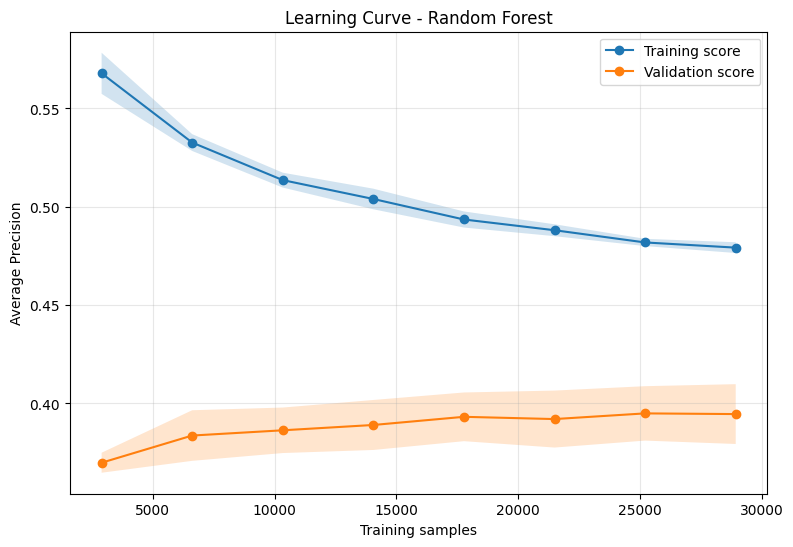

In [87]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_random_forest,
    X=X_train,
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=cv,
    scoring="average_precision",
    n_jobs=-1,
    shuffle=True,
    random_state=RANDOM_STATE
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(9, 6))

plt.plot(
    train_sizes,
    train_mean,
    marker="o",
    label="Training score"
)

plt.plot(
    train_sizes,
    val_mean,
    marker="o",
    label="Validation score"
)

plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)

plt.fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.2
)

plt.xlabel("Training samples")
plt.ylabel("Average Precision")
plt.title("Learning Curve - Random Forest")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

The learning curve suggests that the Random Forest is **overfitting**. With small training sets, the model achieves relatively high training Average Precision (~0.57) but much lower validation performance (~0.37). As more training data is added, the training score steadily decreases while the validation score improves slightly, which is expected as the model sees a more representative sample of the underlying distribution. However, both curves begin to plateau at roughly **0.48 training AP and 0.39–0.40 validation AP**, leaving a persistent generalization gap of about **0.08–0.09**. This indicates relatively high variance: adding more data may provide some additional improvement, but the flattening validation curve suggests that data alone is unlikely to close the gap substantially. Further gains would likely require stronger regularization or reduced model complexity, improved features, better hyperparameter tuning, or potentially a different model.